In this notebook, I train a simple convolutional neural network (CNN)
to classify images from the FashionMNIST dataset

Imports and Device Configuration

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

The FashionMNIST dataset is loaded using torchvision. 
Images are split into training and test sets. 
DataLoaders are used to provide batches of data during training

In [3]:
import torch 
from torch import nn, optim 
from torch.utils.data import DataLoader
from torchvision import datasets,transforms 

from src.model import SimpleCNN

device ="cuda" if torch.cuda.is_available() else "cpu"
device 

'cpu'

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

train_dataset.classes

100.0%
100.0%
100.0%
100.0%


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

A simple convolutional neural network (CNN) is trained using CrossEntropyLoss and the Adam optimizer 

In [5]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

In [7]:
train_losses, test_losses = [], []
train_accs, test_accs = [], []

epochs = 12 

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f}, Test  Acc: {test_acc:.4f}")

Epoch 1/12
Train Loss: 0.2619, Train Acc: 0.9049
Test  Loss: 0.2765, Test  Acc: 0.9002
Epoch 2/12
Train Loss: 0.2372, Train Acc: 0.9129
Test  Loss: 0.2654, Test  Acc: 0.9047
Epoch 3/12
Train Loss: 0.2174, Train Acc: 0.9205
Test  Loss: 0.2694, Test  Acc: 0.8977
Epoch 4/12
Train Loss: 0.2023, Train Acc: 0.9248
Test  Loss: 0.2471, Test  Acc: 0.9081
Epoch 5/12
Train Loss: 0.1863, Train Acc: 0.9306
Test  Loss: 0.2613, Test  Acc: 0.9059
Epoch 6/12
Train Loss: 0.1744, Train Acc: 0.9355
Test  Loss: 0.2479, Test  Acc: 0.9118
Epoch 7/12
Train Loss: 0.1602, Train Acc: 0.9405
Test  Loss: 0.2462, Test  Acc: 0.9137
Epoch 8/12
Train Loss: 0.1493, Train Acc: 0.9450
Test  Loss: 0.2577, Test  Acc: 0.9084
Epoch 9/12
Train Loss: 0.1387, Train Acc: 0.9497
Test  Loss: 0.2412, Test  Acc: 0.9140
Epoch 10/12
Train Loss: 0.1256, Train Acc: 0.9526
Test  Loss: 0.2519, Test  Acc: 0.9144
Epoch 11/12
Train Loss: 0.1152, Train Acc: 0.9574
Test  Loss: 0.2451, Test  Acc: 0.9209
Epoch 12/12
Train Loss: 0.1070, Train Acc

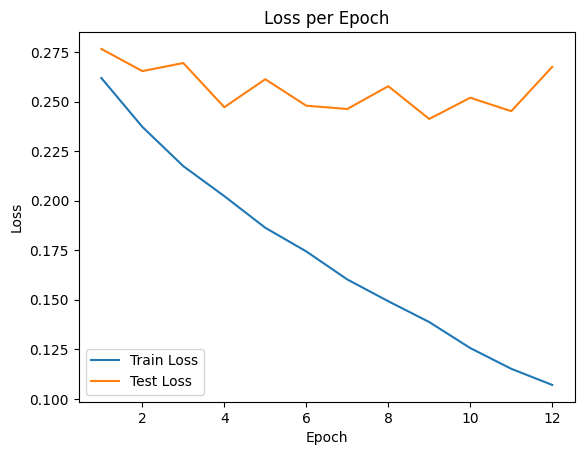

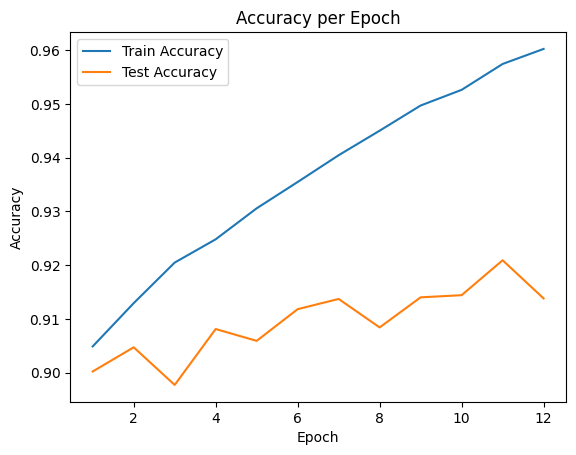

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

# Loss plot
plt.figure()
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("../assets/loss_curve1.png")
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs_range, train_accs, label="Train Accuracy")
plt.plot(epochs_range, test_accs, label="Test Accuracy")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("../assets/accuracy_curve1.png")
plt.show()

The model achieves its best generalization performance around epochs 9–11
Training beyond that does not significantly improve test accuracy